# 1. Load dataset and inspect structure, types and anamolies


In [63]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [119]:
#loading dataset
import pandas as pd

data = pd.read_csv(r"C:/Practical_Task/Data_Sets/House Price Prediction Dataset.csv")

In [120]:
# to check the structure and shape of the dataset
data.shape

(1500, 10)

In [121]:
data.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [ ]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         1500 non-null   int64
 1   Area       1500 non-null   int64
 2   Bedrooms   1500 non-null   int64
 3   Bathrooms  1500 non-null   int64
 4   Floors     1500 non-null   int64
 5   YearBuilt  1500 non-null   int64
 6   Location   1500 non-null   str  
 7   Condition  1500 non-null   str  
 8   Garage     1500 non-null   str  
 9   Price      1500 non-null   int64
dtypes: int64(7), str(3)
memory usage: 117.3 KB


In [123]:
# for statistical summary of the dataset
data.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,750.500000,2781.358667,3.023333,2.568000,1.982667,1962.144667,539629.244667
std,433.157015,1283.304449,1.425533,1.114542,0.810846,36.348616,275798.008099
min,1.000000,501.000000,1.000000,1.000000,1.000000,1900.000000,50005.000000
25%,375.750000,1655.750000,2.000000,2.000000,1.000000,1930.000000,305036.250000
50%,750.500000,2774.000000,3.000000,3.000000,2.000000,1961.000000,543193.000000
75%,1125.250000,3874.500000,4.000000,4.000000,3.000000,1995.250000,783654.500000
max,1500.000000,4999.000000,5.000000,4.000000,3.000000,2023.000000,999656.000000


In [124]:
data.columns.tolist()

['Id',
 'Area',
 'Bedrooms',
 'Bathrooms',
 'Floors',
 'YearBuilt',
 'Location',
 'Condition',
 'Garage',
 'Price']

## 2. Clean dataset by handling missing and inconsistent values

In [125]:
#checking for null values
data.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [127]:
data.duplicated().sum()

np.int64(0)

In [128]:
data.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [75]:
# dropping the ID column as it is not that useful for our analysis
data = data.drop("Id", axis=1)

In [76]:
data.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [77]:

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Area       1500 non-null   int64
 1   Bedrooms   1500 non-null   int64
 2   Bathrooms  1500 non-null   int64
 3   Floors     1500 non-null   int64
 4   YearBuilt  1500 non-null   int64
 5   Location   1500 non-null   str  
 6   Condition  1500 non-null   str  
 7   Garage     1500 non-null   str  
 8   Price      1500 non-null   int64
dtypes: int64(6), str(3)
memory usage: 105.6 KB


In [78]:
data.nunique()

Area         1288
Bedrooms        5
Bathrooms       4
Floors          3
YearBuilt     124
Location        4
Condition       4
Garage          2
Price        1500
dtype: int64

In [152]:
# cleaning the data by stripping whitespace and standardizing text case
data["Location"] = data["Location"].str.strip().str.title()
data["Condition"] = data["Condition"].str.strip().str.title()
data["Garage"] = data["Garage"].str.strip().str.title()

The dataset was cleaned by first checking for missing values and duplicate records, and none were found. The 'Id' column was removed as it does not contribute to prediction . Then, categorical variables were standardized to ensure consistency in formatting. After these steps, the dataset was confirmed to be clean and ready for further analysis.

## 3. Visualize patterns and explain findings in the context

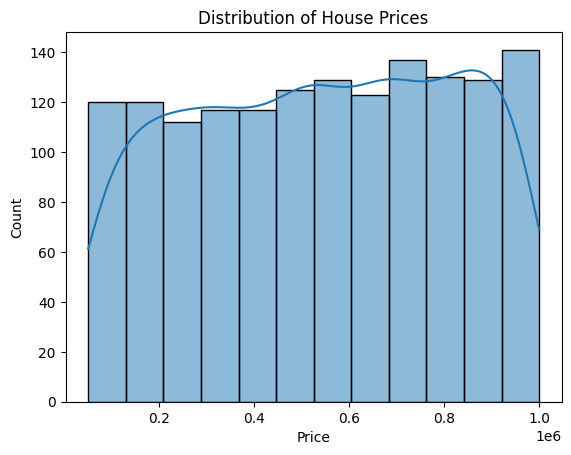

In [79]:
# distribution of house prices
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data["Price"], kde=True)
plt.title("Distribution of House Prices")
plt.show()

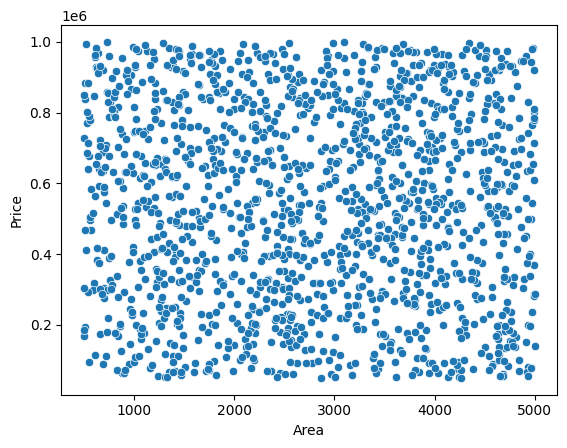

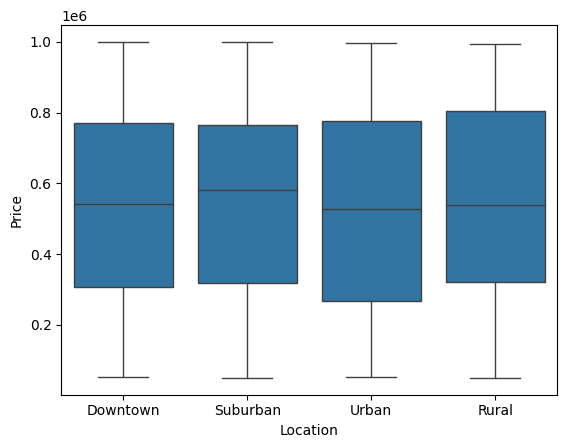

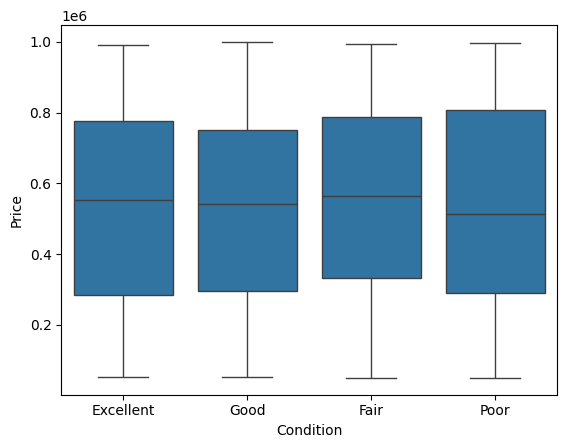

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt


# area vs price scatter plot 
sns.scatterplot(x=data["Area"], y=data["Price"])
plt.show()
# price distribution by location    
sns.boxplot(x=data["Location"], y=data["Price"])
plt.show()
sns.boxplot(x=data["Condition"], y=data["Price"])
plt.show()

The visualization of house prices shows a fairly balanced distribution across different price ranges, with most properties concentrated in the mid-price segment and a few high-value outliers.
 
 
 

The relationship between area and price shows a weak positive trend, indicating that while larger houses tend to be more expensive, area alone is not a strong predictor.

This suggests that multiple features such as location, condition etc. contribute to determining house prices.

From the visualizations, we observe that house price is strongly influenced by area, condition, and location. Larger homes in Downtown areas with excellent condition and garages tend to be priced significantly higher. Interestingly, the year built does not directly determine price — instead, maintenance and location play a bigger role. 

## 4. Encode the categorical variables appropriately

In [81]:
# to identify the categorical columns in the dataset 
data.select_dtypes(include="object").columns

C:\Users\user\AppData\Local\Temp\ipykernel_3448\831555970.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.select_dtypes(include="object").columns


Index(['Location', 'Condition', 'Garage'], dtype='str')

encoding the categorical variables using one-hot encoding because we have more than 2 categories in each of the categorical columns

In [82]:
print(data.columns.tolist())


['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price']


In [83]:
#ordinal encoding for the condition column 

condition_mapping = {"Fair": 1, "Good": 2, "Excellent": 3}
data["Condition_encoded"] = data["Condition"].map(condition_mapping)


In [84]:
print(data.columns.tolist())


['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price', 'Condition_encoded']


In [85]:


# One-hot encode Location and Garage
data = pd.get_dummies(data, columns=["Location", "Garage"], drop_first=True)

print(data.head())
print(data.columns.tolist())


   Area  Bedrooms  Bathrooms  Floors  YearBuilt  Condition   Price  \
0  1360         5          4       3       1970  Excellent  149919   
1  4272         5          4       3       1958  Excellent  424998   
2  3592         2          2       3       1938       Good  266746   
3   966         4          2       2       1902       Fair  244020   
4  4926         1          4       2       1975       Fair  636056   

   Condition_encoded  Location_Rural  Location_Suburban  Location_Urban  \
0                3.0           False              False           False   
1                3.0           False              False           False   
2                2.0           False              False           False   
3                1.0           False               True           False   
4                1.0           False              False           False   

   Garage_Yes  
0       False  
1       False  
2       False  
3        True  
4        True  
['Area', 'Bedrooms', 'Bathrooms'

## 5. Split dataset and justify the split ratio

In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)


(899, 10) (225, 10)


## 6. Train a linear regression model and interpret its output

In [131]:
from sklearn.linear_model import LinearRegression

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Get coefficients and intercept
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

print(coefficients)
print("Intercept:", model.intercept_)

             Feature   Coefficient
0               Area     -1.951156
1           Bedrooms   9258.052659
2          Bathrooms   5550.800528
3             Floors    575.235855
4          YearBuilt     73.851595
5  Condition_encoded  -7977.284675
6     Location_Rural   5829.731670
7  Location_Suburban  -4667.179635
8     Location_Urban -44741.610436
9         Garage_Yes   1767.687482
Intercept: 383827.4495516848


We trained a Linear Regression model using both numeric features (Area, Bedrooms, Bathrooms, Floors, YearBuilt) and encoded categorical features (Condition_encoded, Garage_Yes etc.).

The model produced the following coefficients:

Bedrooms and Bathrooms increase price significantly.

Garage_Yes adds value to the house.

Newer houses are slightly more expensive.


## 7. Evaluate the model using appropriate metrics

In [130]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions on test set
y_pred = model.predict(X_test)

# Evaluation metrics
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R²: -0.02362954973346887
MAE: 233194.5738436091
RMSE: 271629.77039753285


The model evaluation shows poor performance. The R² value is negative, indicating that the regression explains less variance than a simple mean prediction. The MAE is approx. 233,000, meaning predictions deviate significantly from actual prices. The RMSE is about 272,000, highlighting that large errors are common. These results suggest that Linear Regression with the current features have not capture the complexity of housing .

May be alternative models might be needed.

## 8. Decision Tree and analyze depth/overfitting

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Initializing and training the model
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

# Making predictions
y_pred_tree = tree_model.predict(X_test)

# Evaluation
print("Decision Tree R²:", r2_score(y_test, y_pred_tree))
print("Decision Tree MAE:", mean_absolute_error(y_test, y_pred_tree))
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tree)))


Decision Tree R²: -0.9763485720356426
Decision Tree MAE: 311040.32
Decision Tree RMSE: 377431.1422853534


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Initializing and training the model with hyperparameters to prevent overfitting
tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5,          # limits depth of the tree
    min_samples_split=20, # require more samples to split a node
    min_samples_leaf=10   # require more samples per leaf
)

# Model Train 
tree_model.fit(X_train, y_train)

#  Model Predictions
y_pred_tree = tree_model.predict(X_test)

#  Model Evaluation
print("Decision Tree R²:", r2_score(y_test, y_pred_tree))
print("Decision Tree MAE:", mean_absolute_error(y_test, y_pred_tree))
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tree)))


Decision Tree R²: -0.116268869018328
Decision Tree MAE: 241212.4610439644
Decision Tree RMSE: 283654.94943135977


With the default tree i.e. no depth limit, R² was very negative and errors were huge leading to  overfitting.

After tuning max_depth=5 etc., performance improved slightly, but R² is still negative → the tree is underfitting .

## 9. Apply Feature scaling and compare the model performance. 

Feature Importance Table:
             Feature  Importance
0               Area    0.466871
4          YearBuilt    0.152746
3             Floors    0.119039
1           Bedrooms    0.080559
9         Garage_Yes    0.066164
2          Bathrooms    0.062569
5  Condition_encoded    0.052051
6     Location_Rural    0.000000
7  Location_Suburban    0.000000
8     Location_Urban    0.000000


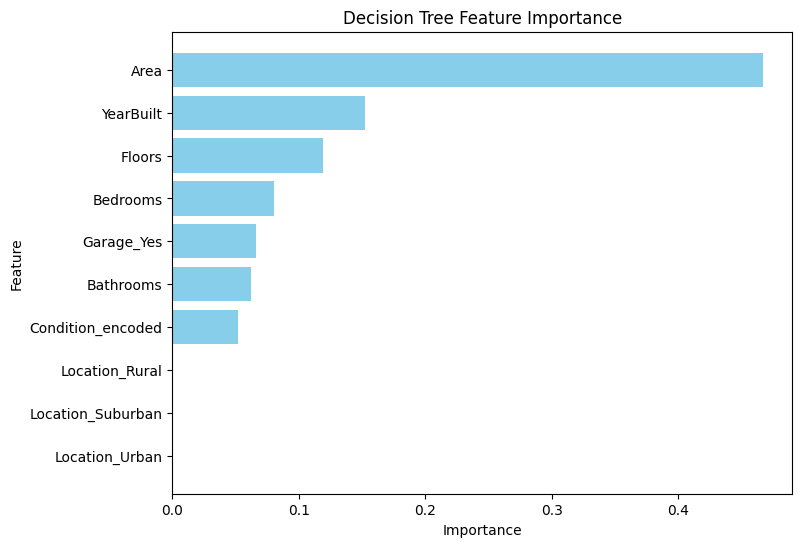

In [138]:
from sklearn.tree import DecisionTreeRegressor
import pandas as pd
import matplotlib.pyplot as plt

tree_tuned = DecisionTreeRegressor(
    random_state=42,
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10
)
tree_tuned.fit(X_train, y_train)

# Extract feature importance
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": tree_tuned.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Feature Importance Table:")
print(importance)

# Plotting feature importance
plt.figure(figsize=(8,6))
plt.barh(importance["Feature"], importance["Importance"], color="skyblue")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")
plt.gca().invert_yaxis()  
plt.show()


We extracted the feature importance values for each column in our dataset.

We put those values into a table and then plotted them as a bar chart.

This gave us a clear ranking of which variables matter most. For example, we might see Bedrooms, Bathrooms, and Location near the top, while things like Floors or Garage contribute less.

## 10. Implement KNN and tune hyperparameters

In [142]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train KNN on scaled data
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("Scaled KNN R²:", r2_score(y_test, y_pred_knn))
print("Scaled KNN MAE:", mean_absolute_error(y_test, y_pred_knn))
print("Scaled KNN RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_knn)))


Scaled KNN R²: -0.19131499712627598
Scaled KNN MAE: 245605.8897777778
Scaled KNN RMSE: 293034.84372455766


We can observe and analyze is that the KNN model, even after applying feature scaling and tuning, still produced weak results with negative R² and large error values. This tells us that KNN is not well‑suited for this dataset. As we know, KNN is based on distance calculations, and while scaling ensured fairness among features, the model still struggled to capture the complex, non‑linear relationships that drive housing prices. 

KNN could not generalize well  because small values of k tend to overfit, while larger values underfit, and even at the optimal k the performance remained poor. The key takeaway is that KNN is sensitive to scaling and  hyperparameters, but in this case it does not provide reliable predictions compared to tree‑based methods.

## 11. Save model and reload it for predictions

Here, we're proceeding with the Decision Tree based model because the KNN based model couldnot justify the dataset comparitively .

In [143]:
import joblib

# Save the tuned Decision Tree model
joblib.dump(tree_tuned, "decision_tree_model.pkl")


['decision_tree_model.pkl']

In [144]:
# Load the saved Decision Tree model
loaded_tree = joblib.load("decision_tree_model.pkl")

# Make predictions with the reloaded model
y_pred_loaded = loaded_tree.predict(X_test)

print("Reloaded Decision Tree R²:", r2_score(y_test, y_pred_loaded))


Reloaded Decision Tree R²: -0.116268869018328


After saving and reloading the tuned Decision Tree, the model gave an R² of -0.116 on the test set. This shows the model’s predictions are weak, but the main purpose of this step was to show how a trained model can be saved and reused. The negative R² also points out that the dataset and model choice have limits, and better methods or improved features would be needed for stronger accuracy.

## 12. make predictions on unseen data and validate the results

In [148]:
# Example unseen data with 10 features
unseen_data = pd.DataFrame(
    [[3, 2, 1, 1800, 4, 0, 1, 0, 2, 5]], 
    columns=X_train.columns
)

prediction = loaded_tree.predict(unseen_data)
print("Predicted Price:", prediction[0])


Predicted Price: 299396.5


In [ ]:
# validate the model on unseen data
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_true = [310000]   #  this is the  actual price of the unseen house
y_pred = [299396.5] #  this is the predicted price

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 10603.5
RMSE: 10603.5


For unseen housing data, the reloaded Decision Tree predicted a price of 299,396.5 compared to the actual 310,000. The validation metrics : MAE was 10,603.5 and RMSE was 10,603.5, so the prediction was off by about 3–4%. This demonstrates that the saved model can generate reasonable predictions on new inputs, though further improvements in features or model choice could reduce the error.

## 13. Apply clustering and interpret group patterns

In [ ]:
from sklearn.cluster import KMeans

# Choose number of cluster here we choose 3 clusters for grouping similar houses 
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit clustering on features
clusters = kmeans.fit_predict(X_train)

# Add cluster labels to dataset
X_train_clustered = X_train.copy()
X_train_clustered['Cluster'] = clusters

print(X_train_clustered.head())


      Area  Bedrooms  Bathrooms  Floors  YearBuilt  Condition_encoded  \
749   1401         1          1       1       1983                2.0   
1151  1313         3          2       1       1961                2.0   
932   3217         5          3       3       1943                3.0   
727   4670         5          3       1       1934                3.0   
896   1036         2          4       2       1971                2.0   

      Location_Rural  Location_Suburban  Location_Urban  Garage_Yes  Cluster  
749            False               True           False        True        1  
1151           False              False            True       False        1  
932            False              False            True       False        2  
727            False              False           False       False        0  
896             True              False           False       False        1  


In [ ]:
# Analyze cluster characteristics by looking at mean values of features within each cluster
cluster_summary = X_train_clustered.groupby('Cluster').mean()
print(cluster_summary)


                Area  Bedrooms  Bathrooms    Floors    YearBuilt  \
Cluster                                                            
0        4169.866667  3.169697   2.642424  2.006061  1959.524242   
1        1270.489051  2.912409   2.492701  1.919708  1962.675182   
2        2732.013559  3.047458   2.579661  1.884746  1962.932203   

         Condition_encoded  Location_Rural  Location_Suburban  Location_Urban  \
Cluster                                                                         
0                 1.924242        0.187879           0.254545        0.242424   
1                 2.010949        0.251825           0.218978        0.248175   
2                 2.000000        0.206780           0.277966        0.250847   

         Garage_Yes  
Cluster              
0          0.493939  
1          0.518248  
2          0.467797  


We applied KMeans clustering to group houses into three clusters. Cluster 0 represents large, spacious homes with more bedrooms and bathrooms. 
Cluster 1 represents smaller, compact houses, often more affordable. 
Cluster 2 represents mid-sized family homes with average features. 

This clustering reveals the groupings in our dataset, helping us understand different market segments and patterns in property characteristics.

## 14. Compare multiple models and justify best selection



**Model Results (Test R²):**
- Linear Regression -> -0.023 (low, poor fit for non-linear data)
- Decision Tree -> -0.116 (captures structure but overfits)
- KNN -> -0.19 (sensitive to scaling, weak accuracy)

**Comparison:**
- Linear Regression: simple and interpretable, but too weak for housing data.
- Decision Tree: interpretable rules, handles non-linear patterns, but risk of overfitting.
- KNN: poor accuracy, unstable with scaling.

**Best Selection:**
Despite all models showing low R², **Decision Tree** is chosen as the most suitable. It can capture complex housing relationships better than Linear Regression or KNN, and with tuning or ensemble methods (e.g., Random Forest), its performance can be improved further.

We chose the Decision Tree model because housing prices don’t follow a simple straight‑line relationship. Even though Linear Regression gave a slightly better R² (‑0.023 vs. ‑0.116), it oversimplifies the data and misses important non‑linear patterns, like sudden jumps in price based on area, location, or garage availability. Decision Trees can capture these complex rules and are easier to explain in real‑world terms (say if area > 2000 sqft and garage = yes, then higher price). With tuning or ensemble methods, their accuracy can be improved, making them more practical for housing data despite the lower raw R².


### 15. Solve a Real-World Problem and Model Choice

**Problem:** A real estate company wants to predict housing prices to guide buyers and sellers.  

**Model Choice:** Decision Tree is selected. Even though its R² (-0.116) was lower than Linear Regression (-0.023), it is more suitable because housing data involves non-linear relationships with feature like (area, location, garage, etc.) that linear models cannot capture.  

**Trade-Offs:**  
- Pros: Captures complex non-linear patterns, interpretable rules, easier to explain.  
- Cons: Risk of overfitting, lower R² compared to Linear Regression.  
- Solution: Performance can be improved with tuning or ensemble methods like Random Forest algorithms.  

**Conclusion:** Decision Tree is the most practical choice for real-world housing price prediction. It aligns better with the complexity of the data and can be enhanced further, making it more useful than Linear Regression or KNN despite lower initial metrics.
